In [1]:
import os
os.makedirs("data/categoric", exist_ok=True)

In [2]:
from prepare_dataset import PrepareDataset
import numpy as np
import tensorflow as tf
import pandas as pd
from math import sqrt

In [3]:
ds = PrepareDataset("data/treino.csv")
df = ds.df

## Dataframe para dataset


In [4]:
CAT_COLS = ['category', 'job', 'merchant', 'state', 'city']

NUM_COLS = ['gender','lat','long','city_pop', 'amt',
            'time_sin','time_cos','date_sin','date_cos', 'lat_mean', 'lat_std',
            'long_mean', 'long_std', 'amt_mean', 'amt_std', 'time_sin_mean',
            'time_sin_std', 'time_cos_mean', 'time_cos_std', 'date_sin_mean',
            'date_sin_std', 'date_cos_mean', 'date_cos_std']

TARGET = 'is_fraud'

In [5]:
df_train, df_val, df_test = ds.train_val_test_split(df)

def drop_majority_class(df, target="is_fraud", drop_frac=0.2, random_state=42):
    # separa classes
    df_majority = df[df[target] == 0]
    df_minority = df[df[target] == 1]

    # remove 20% da classe majoritária
    df_majority_reduced = df_majority.sample(
        frac=(1 - drop_frac),
        random_state=random_state
    )

    # junta novamente
    df_new = pd.concat([df_majority_reduced, df_minority])

    # embaralha
    df_new = df_new.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    return df_new

def df_to_dataset(dframe, shuffle=True, batch_size=2048):
    # inputs em formato dict: {nome_coluna: array}
    x = {}
    for c in CAT_COLS:
        x[c] = dframe[c].to_numpy(dtype=np.int32)  # Embedding usa int32/int64
    x["numeric"] = dframe[NUM_COLS].to_numpy(dtype=np.float32)

    y = dframe[TARGET].to_numpy(dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dframe), 200_000), reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

df_train = drop_majority_class(df_train, drop_frac=0.2)
train_ds = df_to_dataset(df_train)
val_ds   = df_to_dataset(df_val, shuffle=False)
test_ds  = df_to_dataset(df_test, shuffle=False)

In [14]:
n_category = 14
n_job      = 171
n_merchant = 693
n_state    = 39
n_city     = 180

dim_category = 8
dim_job      = 16
dim_merchant = 32
dim_state    = 16
dim_city     = 16

## Modelo

In [ ]:
from tensorflow.keras import layers, Model

def build_model():
    # Inputs categóricos (escalares)
    in_category = layers.Input(shape=(), dtype=tf.int32, name="category")
    in_job      = layers.Input(shape=(), dtype=tf.int32, name="job")
    in_merchant = layers.Input(shape=(), dtype=tf.int32, name="merchant")
    in_state    = layers.Input(shape=(), dtype=tf.int32, name="state")
    in_city     = layers.Input(shape=(), dtype=tf.int32, name="city")

    # Input numérico (vetor)
    in_num = layers.Input(shape=(len(NUM_COLS),), dtype=tf.float32, name="numeric")

    # Embeddings
    e_category = layers.Embedding(n_category, dim_category, name="emb_category", embeddings_regularizer=tf.keras.regularizers.l2(1e-6))(in_category)
    e_job      = layers.Embedding(n_job, dim_job, name="emb_job", embeddings_regularizer=tf.keras.regularizers.l2(1e-6))(in_job)
    e_merchant = layers.Embedding(n_merchant, dim_merchant, name="emb_merchant", embeddings_regularizer=tf.keras.regularizers.l2(1e-6))(in_merchant)
    e_state    = layers.Embedding(n_state, dim_state, name="emb_state", embeddings_regularizer=tf.keras.regularizers.l2(1e-6))(in_state)
    e_city     = layers.Embedding(n_city, dim_city, name="emb_city", embeddings_regularizer=tf.keras.regularizers.l2(1e-6))(in_city)

    e_category = layers.Flatten()(e_category)
    e_job      = layers.Flatten()(e_job)
    e_merchant = layers.Flatten()(e_merchant)
    e_state    = layers.Flatten()(e_state)
    e_city     = layers.Flatten()(e_city)

    # Concatenar embeddings + numéricas
    x = layers.Concatenate()([e_category, e_job, e_merchant, e_state, e_city, in_num])

    # MLP
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)


    # Logit (sem sigmoid aqui — vamos usar loss from_logits=True)
    out = layers.Dense(1, name="logit")(x)

    model = Model(
        inputs={"category": in_category, "job": in_job, "merchant": in_merchant,
                "state": in_state, "city": in_city, "numeric": in_num},
        outputs=out
    )
    return model

model = build_model()
#model.summary()

In [ ]:
num_items = df_train["is_fraud"].value_counts().to_dict()
print(num_items)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

metrics = [
    tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.Precision(name="precision"),
]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=500,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=3)
    ]
)


{0.0: 89774, 1.0: 1223}
Epoch 1/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.8239 - pr_auc: 0.0121 - precision: 0.0109 - recall: 0.2444 - val_loss: 0.5340 - val_pr_auc: 0.0107 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.6485 - pr_auc: 0.0214 - precision: 0.0238 - recall: 0.2999 - val_loss: 0.4561 - val_pr_auc: 0.0107 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5553 - pr_auc: 0.0342 - precision: 0.0373 - recall: 0.2717 - val_loss: 0.3850 - val_pr_auc: 0.0107 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 4/500
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4688 - pr_auc: 0.0532 - precision: 0.0562 - recall: 0.2286 - val_loss: 0.3220 - val_pr_auc: 0.0178 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 5/

# Evaluate


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [21]:
def make_predictions(model, dataset):
    y_true = []
    logits = []

    for x, y in dataset:
        model_output = model(x, training=False)
        logits += model_output.numpy().reshape((-1)).tolist()
        y_true += y.numpy().reshape((-1)).tolist()

    y_true = np.array(y_true)
    logits = np.array(logits)

    probs = tf.math.sigmoid(logits)

    return y_true, probs
y_true, probs = make_predictions(model, val_ds)



In [27]:
def find_best_threshold(y_true, probs, min_precision=0.6):
    """
        Find the threshold that maximizes recall
    """
    thresholds = np.linspace(0.0, 1.0, 500)

    best = {
        "recall": -1,
        "precision": None,
        "accuracy": None,
        "confusion_matrix": None,
        "th": None,
    }


    for t in thresholds:
        y_pred = (probs >= t).numpy()

        if y_pred.sum() == 0:
            continue

        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)

        if recall > best["recall"] and precision > min_precision:
            best.update({
                "recall": recall,
                "th": float(t),
                "precision": precision,
                "accuracy": accuracy_score(y_true, y_pred),
                "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            })

    return best

best = find_best_threshold(y_true, probs)
best

{'recall': 0.875,
 'precision': 0.6129032258064516,
 'accuracy': 0.9927699003228977,
 'confusion_matrix': array([14010,    84,    19,   133]),
 'th': 0.05410821643286573}

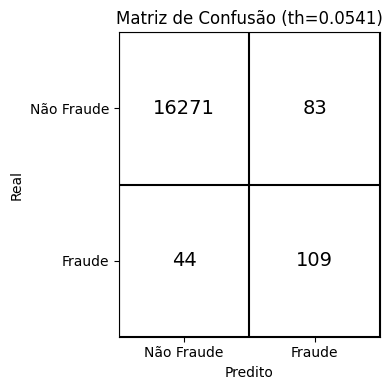

{'recall': 0.7124183006535948,
 'precision': 0.5677083333333334,
 'accuracy': 0.9923062942993881,
 'cm': array([[16271,    83],
        [   44,   109]])}

In [38]:
def evaluate(model, dataset, th):
    y_true, probs = make_predictions(model, dataset)
    y_pred = (probs >= th).numpy()

    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fraude"])


    # ===== Plot SEM preenchimento =====
    fig, ax = plt.subplots(figsize=(4, 4))

    # Define limites da grade manualmente
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    # Marcações
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Não Fraude", "Fraude"])
    ax.set_yticklabels(["Não Fraude", "Fraude"])

    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusão (th={th:.4f})")

    # Desenha linhas da grade
    for i in range(3):
        ax.axhline(i - 0.5, color="black")
        ax.axvline(i - 0.5, color="black")

    # Insere valores
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=14)

    plt.tight_layout()
    plt.show()

    return {
        "recall": recall,
        "precision": precision,
        "accuracy": accuracy,
        "cm": cm
    }

evaluate(model, test_ds, best["th"])

In [20]:
model.save("modelo.keras")